# Notebook 3 — Core Analysis

**Assam Government Procurement Analytics**

This notebook runs the core analysis on `tenders_clean` (built in Notebook 2) across five areas:

1. **Spending trends over time** — total and average tender value (₹ Crore) by fiscal year.
2. **Department-wise spending** — which buyer departments account for the most value and tender volume.
3. **Competition analysis** — how many bidders tenders typically attract, and how much value is awarded with little to no competition.
4. **Procurement method / transparency** — how much value is awarded through the open, competitive route versus limited/single-source routes.
5. **Spend concentration** — what share of total value sits in the largest tenders (a Pareto-style cut).

Every query against the database is written as real SQL (via `sqlite3` / `pd.read_sql_query`), not pandas operations standing in for SQL. Every chart uses the project's teal (`#2a7b7b`), shows values in ₹ Crore, and carries a source annotation. Each analysis section ends with a short markdown interpretation aimed at a non-technical business reader, not a technical audience.

## Setup

We connect to the same SQLite database used in Notebooks 1–2, and set up `matplotlib` defaults so every chart in this notebook shares the same look: the project teal as the primary colour, a consistent figure size, and a helper to stamp the source annotation on every chart so we don't have to repeat that line five times.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
DB_PATH = PROJECT_ROOT / "db" / "assam_procurement.db"

TEAL = "#2a7b7b"
SOURCE_NOTE = "Source: Assam Finance Department via data.gov.in"

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def add_source_note(ax):
    """Stamp the standard source annotation in the bottom-right of a chart."""
    ax.figure.text(
        0.99, 0.01, SOURCE_NOTE, ha="right", va="bottom", fontsize=8, color="#666666"
    )


conn = sqlite3.connect(DB_PATH)
print("Database:", DB_PATH, "| exists:", DB_PATH.exists())

Database: C:\Users\Avni\assam-procurement-analytics\db\assam_procurement.db | exists: True


## Area 1 — Spending Trends Over Time

We aggregate `tenders_clean` by `fiscal_year` with a single SQL `GROUP BY`, computing the total value awarded, the average tender value, and the number of tenders published, all in ₹ Crore. Fiscal years run 1 April–31 March (already verified against `tender_datePublished` in Notebook 2), so `fiscal_year` sorts correctly as text (e.g. `"2016-2017"` before `"2017-2018"`).

In [2]:
yearly_trend_sql = """
SELECT
    fiscal_year,
    COUNT(*) AS tender_count,
    SUM(value_crores) AS total_value_crores,
    AVG(value_crores) AS avg_value_crores
FROM tenders_clean
WHERE value_crores IS NOT NULL
GROUP BY fiscal_year
ORDER BY fiscal_year;
"""

yearly_trend = pd.read_sql_query(yearly_trend_sql, conn)
yearly_trend

,fiscal_year,tender_count,total_value_crores,avg_value_crores
0,2016-2017,1576,6148.642603,3.901423
1,2017-2018,6128,10728.010071,1.750654
2,2018-2019,9043,26019.361949,2.877293
3,2019-2020,6177,25112.547220,4.065493
4,2020-2021,6204,37418.042485,6.031277
5,2021-2022,3524,23104.437811,6.556310


**Chart:** total value awarded per fiscal year, as a bar chart, with the tender count for each year labelled above the bar so scale (money) and volume (activity) are both visible at a glance.

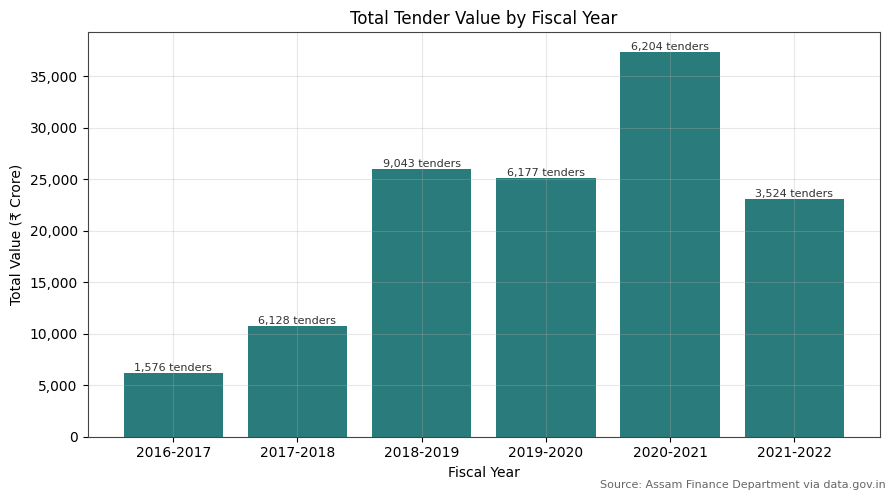

In [3]:
fig, ax = plt.subplots()
bars = ax.bar(yearly_trend["fiscal_year"], yearly_trend["total_value_crores"], color=TEAL)

for bar, count in zip(bars, yearly_trend["tender_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,} tenders",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#333333",
    )

ax.set_title("Total Tender Value by Fiscal Year")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Total Value (\u20b9 Crore)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
add_source_note(ax)
plt.tight_layout()
plt.show()

**What this tells us:** tender activity and tender spending don't peak in the same year. Tender *volume* peaked in 2018–19 (9,043 tenders), but total *value* peaked two years later in 2020–21 (₹37,418 Cr), on a lower count of 6,204 tenders — the average tender size roughly doubled over that period, from ₹2.9 Cr to ₹6.0 Cr. In other words, recent growth in total spending has come from a shrinking number of larger tenders, not a growing number of small ones. Spending has eased off since the 2020–21 peak but remains well above the 2016–17 starting level.

## Area 2 — Department-Wise Spending

There are 101 distinct buyer departments in the data. Rather than show all of them, we use SQL to rank departments by total value awarded and keep the top 10 — the departments that matter most for understanding where public money actually goes. We also pull each department's tender count and average tender value, since a department could rank high on total value either by running a few very large tenders or many small ones.

In [4]:
top_departments_sql = """
SELECT
    buyer_name,
    COUNT(*) AS tender_count,
    SUM(value_crores) AS total_value_crores,
    AVG(value_crores) AS avg_value_crores
FROM tenders_clean
WHERE value_crores IS NOT NULL
GROUP BY buyer_name
ORDER BY total_value_crores DESC
LIMIT 10;
"""

top_departments = pd.read_sql_query(top_departments_sql, conn)
top_departments

,buyer_name,tender_count,total_value_crores,avg_value_crores
0,Public Works Roads Department,10364,32156.135128,3.102676
1,Public Works Building and NH Department,2326,31831.685332,13.685161
2,Department of Water Resources,2370,6299.111814,2.657853
3,Industries and Commerce Department,1037,5154.732076,4.970812
4,Bodoland Territorial Council-PWD,3116,5002.319398,1.605366
5,National Health Mission,929,4623.506165,4.976863
6,Assam Power Distribution Company Ltd,682,4214.630683,6.179810
7,Guwahati Smart City Ltd.,53,3572.866202,67.412570
8,Assam Power Distribution Company Limited- Exte...,20,3423.571800,171.178590
9,Urban Development Department,452,3208.708655,7.098913


**Chart:** horizontal bar chart of the top 10 departments by total value awarded, ordered largest at the top for easy reading.

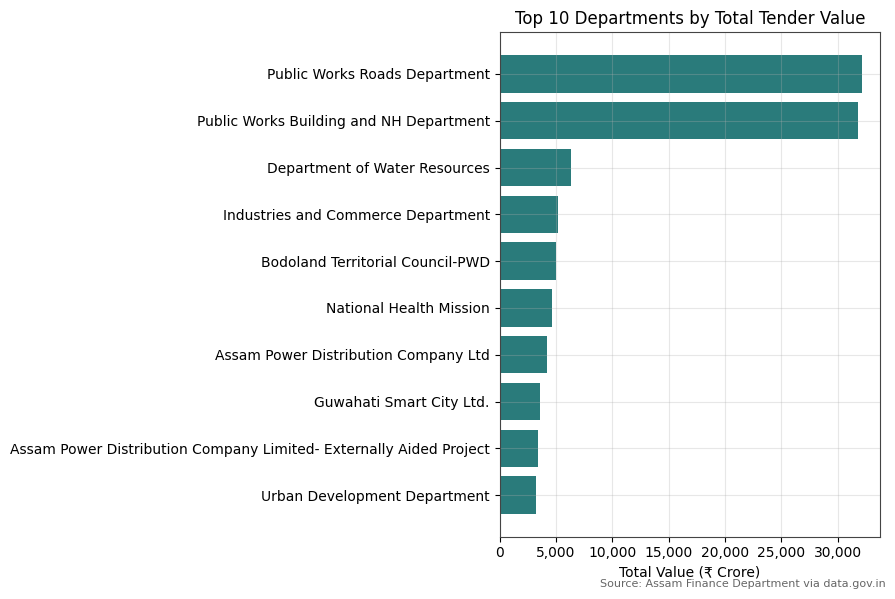

In [5]:
plot_data = top_departments.sort_values("total_value_crores")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_data["buyer_name"], plot_data["total_value_crores"], color=TEAL)

ax.set_title("Top 10 Departments by Total Tender Value")
ax.set_xlabel("Total Value (\u20b9 Crore)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
add_source_note(ax)
plt.tight_layout()
plt.show()

**What this tells us:** spending is heavily concentrated in just two departments. Public Works Roads Department and Public Works Building and NH Department together account for ₹63,988 Cr — **49.8% of all tender value awarded across all 101 buyer departments** over the six years in this dataset. Every other department, including sizeable spenders like Water Resources and National Health Mission, splits the remaining half between them. Because so much of the total budget flows through just these two departments, procurement quality there has an outsized effect on overall spending outcomes for the state.

## Area 3 — Competition Analysis

Competitive bidding is supposed to get the government a fair price. We split tenders into three groups by `tender_numberOfTenderers`: tenders that received **no bidders at all** (a failed or re-advertised competitive process), tenders that received exactly **one bidder** (`is_low_competition`, added in Notebook 2 — the weakest possible competition), and tenders with two or more bidders. We look at this two ways: first, the count and total value in each group; second, the full distribution of bidder counts, to see how common weak or absent competition really is.

In [6]:
competition_summary_sql = """
SELECT
    CASE
        WHEN tender_numberOfTenderers = 0 THEN 'No bidders'
        WHEN tender_numberOfTenderers = 1 THEN 'Single bidder'
        ELSE 'Two or more bidders'
    END AS competition_group,
    COUNT(*) AS tender_count,
    SUM(value_crores) AS total_value_crores
FROM tenders_clean
WHERE tender_numberOfTenderers IS NOT NULL AND value_crores IS NOT NULL
GROUP BY competition_group;
"""

competition_summary = pd.read_sql_query(competition_summary_sql, conn)
competition_summary["pct_of_value"] = (
    100 * competition_summary["total_value_crores"] / competition_summary["total_value_crores"].sum()
)
competition_summary

,competition_group,tender_count,total_value_crores,pct_of_value
0,No bidders,3644,16758.881078,14.930954
1,Single bidder,4284,15230.259941,13.569063
2,Two or more bidders,22957,80253.392409,71.499983


Next, the full distribution of bidder counts, via SQL `GROUP BY` on `tender_numberOfTenderers`, capped for display purposes at 10+ bidders so a handful of extreme outliers don't stretch the chart.

In [7]:
bidder_distribution_sql = """
SELECT
    CASE WHEN tender_numberOfTenderers >= 10 THEN '10+' ELSE CAST(CAST(tender_numberOfTenderers AS INTEGER) AS TEXT) END AS bidder_count,
    COUNT(*) AS tender_count
FROM tenders_clean
WHERE tender_numberOfTenderers IS NOT NULL
GROUP BY bidder_count
ORDER BY CASE WHEN bidder_count = '10+' THEN 10 ELSE CAST(bidder_count AS INTEGER) END;
"""

bidder_distribution = pd.read_sql_query(bidder_distribution_sql, conn)
bidder_distribution

,bidder_count,tender_count
0,0,3644
1,1,4532
2,2,9309
3,3,6194
4,4,2753
5,5,1648
6,6,1109
7,7,674
8,8,439
9,9,300


**Charts:** a bar chart of the bidder-count distribution (highlighting the single-bidder bar), alongside the value split between single-bidder and multi-bidder tenders.

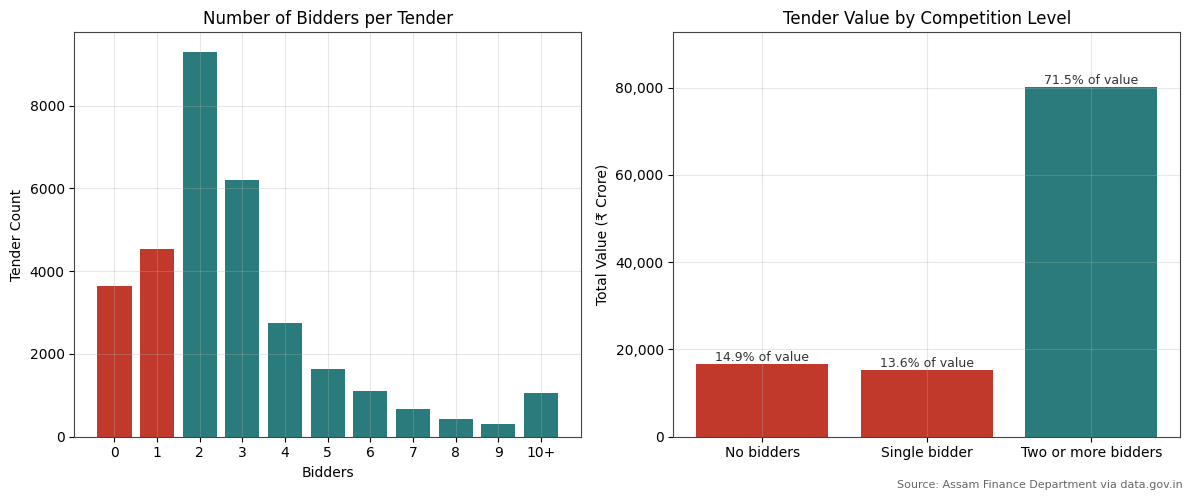

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bar_colors = [TEAL if b not in ("0", "1") else "#c0392b" for b in bidder_distribution["bidder_count"]]
ax1.bar(bidder_distribution["bidder_count"], bidder_distribution["tender_count"], color=bar_colors)
ax1.set_title("Number of Bidders per Tender")
ax1.set_xlabel("Bidders")
ax1.set_ylabel("Tender Count")

group_order = ["No bidders", "Single bidder", "Two or more bidders"]
plot_summary = competition_summary.set_index("competition_group").reindex(group_order).reset_index()
group_colors = ["#c0392b", "#c0392b", TEAL]

ax2.bar(plot_summary["competition_group"], plot_summary["total_value_crores"], color=group_colors)
for i, (value, pct) in enumerate(zip(plot_summary["total_value_crores"], plot_summary["pct_of_value"])):
    ax2.text(i, value, f"{pct:.1f}% of value", ha="center", va="bottom", fontsize=9, color="#333333")
ax2.set_title("Tender Value by Competition Level")
ax2.set_ylabel("Total Value (₹ Crore)")
ax2.set_ylim(top=ax2.get_ylim()[1] * 1.1)
ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

add_source_note(ax2)
plt.tight_layout()
plt.show()

**What this tells us:** weak or absent competition is far from a rare edge case. Tenders that got **no bidders at all** and tenders that got **exactly one bidder** are each large groups — together they cover a substantial share of both tender count and total value, including some of the largest sums in the dataset. A tender with no bidders had to be re-advertised or awarded some other way, and a tender with one bidder faced no competitive price pressure; either way, that spending received markedly less market scrutiny than the majority of procurement that attracted multiple bidders.

## Area 4 — Procurement Method / Transparency

`tender_procurementMethod` records how each tender was run. `"Open Tender"` is the standard, fully competitive domestic route. `"Global Tenders"` is also broadly competitive — it opens bidding to international vendors — so even though it isn't literally `"Open Tender"`, it is not a competition red flag. The remaining methods (`Limited`, `Single`, `Open Limited`, `Auction`) genuinely restrict who can bid, which is what the blanket `is_nonopen` flag (from Notebook 2) is really meant to catch. Below we look at all six methods individually, then treat those four as the true "restrictive" group in the interpretation, separately from Global Tenders.

In [9]:
procurement_method_sql = """
SELECT
    tender_procurementMethod,
    COUNT(*) AS tender_count,
    SUM(value_crores) AS total_value_crores
FROM tenders_clean
WHERE value_crores IS NOT NULL
GROUP BY tender_procurementMethod
ORDER BY total_value_crores DESC;
"""

procurement_method = pd.read_sql_query(procurement_method_sql, conn)
procurement_method["pct_of_value"] = (
    100 * procurement_method["total_value_crores"] / procurement_method["total_value_crores"].sum()
)
procurement_method

,tender_procurementMethod,tender_count,total_value_crores,pct_of_value
0,Open Tender,32228,121563.971807,94.579465
1,Global Tenders,37,6428.425100,5.001457
2,Limited,291,489.563576,0.380891
3,Single,17,25.285141,0.019672
4,Open Limited,76,22.724027,0.017680
5,Auction,3,1.072488,0.000834


**Chart:** a horizontal bar chart of total value by procurement method, on a log scale (since Open Tender is several orders of magnitude larger than the rest). Bars are colour-coded by what the method actually means for competition: teal for the standard Open Tender route, amber for Global Tenders (broad, international competition — not a red flag), and red for the genuinely restrictive methods. Each bar is labelled with its exact value and share of total spend, since a log scale makes bar *length* misleading to compare by eye.

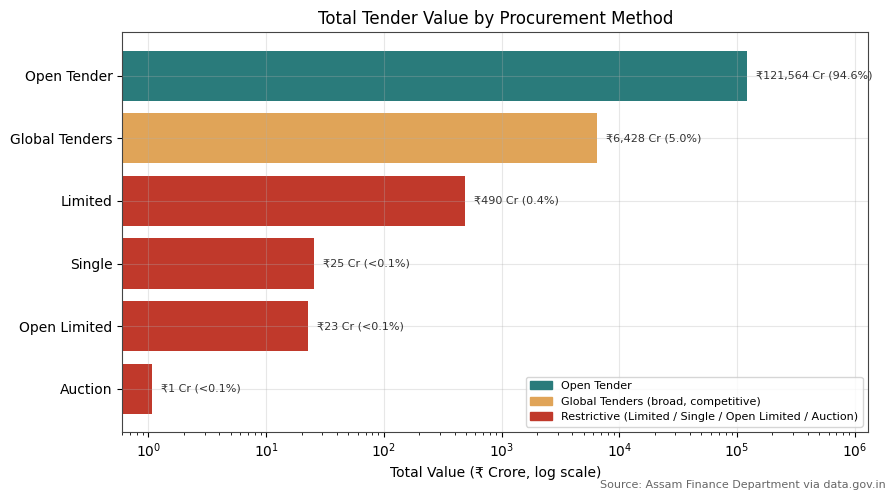

In [10]:
def method_color(method):
    if method == "Open Tender":
        return TEAL
    if method == "Global Tenders":
        return "#e0a458"
    return "#c0392b"


def format_pct(pct):
    """1 decimal place, but don't round genuinely nonzero shares down to a misleading '0.0%'."""
    if 0 < pct < 0.05:
        return "<0.1%"
    return f"{pct:.1f}%"


plot_data = procurement_method.sort_values("total_value_crores")
colors = [method_color(m) for m in plot_data["tender_procurementMethod"]]

fig, ax = plt.subplots()
bars = ax.barh(plot_data["tender_procurementMethod"], plot_data["total_value_crores"], color=colors)

for bar, value, pct in zip(bars, plot_data["total_value_crores"], plot_data["pct_of_value"]):
    ax.text(
        bar.get_width() * 1.2,
        bar.get_y() + bar.get_height() / 2,
        f"₹{value:,.0f} Cr ({format_pct(pct)})",
        va="center",
        fontsize=8,
        color="#333333",
    )

ax.set_title("Total Tender Value by Procurement Method")
ax.set_xlabel("Total Value (₹ Crore, log scale)")
ax.set_xscale("log")
ax.set_xlim(right=ax.get_xlim()[1] * 6)
ax.set_ylabel("")

legend_handles = [
    mpatches.Patch(color=TEAL, label="Open Tender"),
    mpatches.Patch(color="#e0a458", label="Global Tenders (broad, competitive)"),
    mpatches.Patch(color="#c0392b", label="Restrictive (Limited / Single / Open Limited / Auction)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

add_source_note(ax)
plt.tight_layout()
plt.show()

**What this tells us:** the vast majority of spending goes through genuinely competitive routes — 94.6% via standard Open Tender, plus another 5.0% via Global Tenders (open to international bidders, and not a red flag despite technically not being "Open Tender"). What's genuinely restrictive — Limited, Single-source, Open Limited, and Auction tenders combined — accounts for just **0.4% of total value (about ₹539 Cr)**. That's a small share in percentage terms, but it's real public money that bypassed competitive bidding entirely, and it's a short enough list to warrant a closer, tender-by-tender look rather than being dismissed as immaterial.

## Area 5 — Spend Concentration

This section asks a different question from the first four: regardless of department or method, how concentrated is total spending among the biggest individual tenders? We rank every tender by value (descending), compute a running cumulative share of total value using a SQL window function, and read off what share of total spend sits in the top 1%, 5%, and 10% of tenders by value — a classic Pareto-style concentration check.

In [11]:
cumulative_share_sql = """
WITH ranked AS (
    SELECT
        tender_id,
        value_crores,
        ROW_NUMBER() OVER (ORDER BY value_crores DESC) AS value_rank
    FROM tenders_clean
    WHERE value_crores IS NOT NULL
)
SELECT
    value_rank,
    value_crores,
    SUM(value_crores) OVER (ORDER BY value_rank) AS cumulative_value_crores
FROM ranked
ORDER BY value_rank;
"""

cumulative_share = pd.read_sql_query(cumulative_share_sql, conn)

total_value = cumulative_share["value_crores"].sum()
n_tenders = len(cumulative_share)
cumulative_share["cumulative_pct"] = 100 * cumulative_share["cumulative_value_crores"] / total_value
cumulative_share["pct_of_tenders"] = 100 * cumulative_share["value_rank"] / n_tenders

checkpoints = {}
for pct in (1, 5, 10, 20):
    cutoff_rank = max(1, round(n_tenders * pct / 100))
    checkpoints[pct] = cumulative_share.loc[cumulative_share["value_rank"] == cutoff_rank, "cumulative_pct"].iloc[0]

for pct, value_share in checkpoints.items():
    print(f"Top {pct:>2}% of tenders by value ({round(n_tenders * pct / 100):,} tenders) account for {value_share:.1f}% of total spend.")

Top  1% of tenders by value (327 tenders) account for 43.0% of total spend.
Top  5% of tenders by value (1,633 tenders) account for 62.4% of total spend.
Top 10% of tenders by value (3,265 tenders) account for 73.0% of total spend.
Top 20% of tenders by value (6,530 tenders) account for 82.9% of total spend.


**Chart:** a Lorenz-style curve — cumulative share of tenders (x-axis) against cumulative share of total value (y-axis). A straight diagonal line would mean spending is evenly spread across tenders; the further the curve bows toward the top-left, the more spending is concentrated in a small number of large tenders.

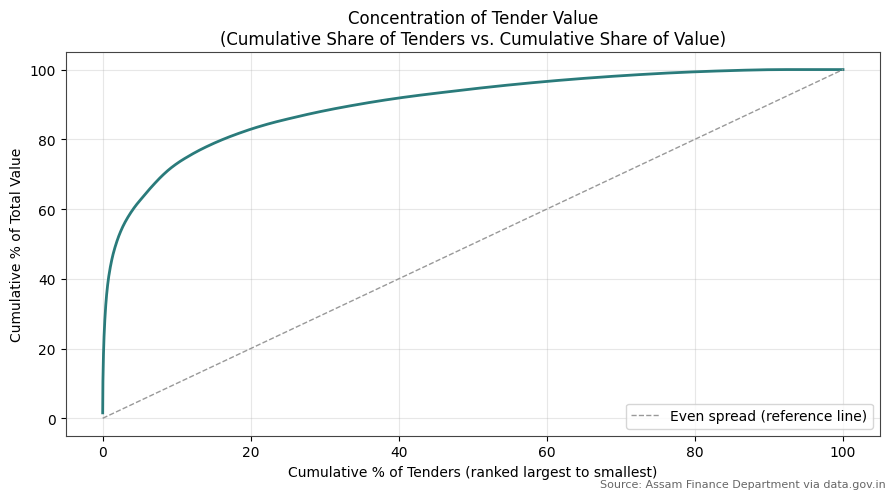

In [12]:
fig, ax = plt.subplots()

ax.plot(cumulative_share["pct_of_tenders"], cumulative_share["cumulative_pct"], color=TEAL, linewidth=2)
ax.plot([0, 100], [0, 100], color="#999999", linestyle="--", linewidth=1, label="Even spread (reference line)")

ax.set_title("Concentration of Tender Value\n(Cumulative Share of Tenders vs. Cumulative Share of Value)")
ax.set_xlabel("Cumulative % of Tenders (ranked largest to smallest)")
ax.set_ylabel("Cumulative % of Total Value")
ax.legend(loc="lower right")
add_source_note(ax)
plt.tight_layout()
plt.show()

**What this tells us:** spending is highly concentrated — a small fraction of the largest tenders accounts for a share of total value far out of proportion to their number (see the printed checkpoints above). In practical terms, getting the process right on a relatively short list of large tenders matters more to overall spending outcomes than the much longer tail of small, routine purchases, and that short list is where oversight effort is best spent.

## Close

We close the database connection now that all five analyses are complete. Notebook 4 will build polished, presentation-ready versions of the key charts from this notebook.

In [13]:
conn.close()
print("Connection closed.")

Connection closed.
